Step 1: Install & Import Libraries

In [ ]:
# All libraries are pre-installed in Google Colab — no pip install needed!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print(' All libraries imported successfully!')


 All libraries imported successfully!


Step 2: Upload & Load the Data

In [ ]:
from google.colab import files
uploaded = files.upload()  # <- click this and upload your train.csv

df = pd.read_csv('/content/drive/MyDrive/superstore sales/train.csv')
print(f' Data loaded: {df.shape[0]:,} rows and {df.shape[1]} columns')
df.head()

 Data loaded: 9,800 rows and 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 3: Data Cleaning & Exploration

In [ ]:
# Check data types and missing values
print('=== DATA INFO ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== SALES SUMMARY ===')
print(df['Sales'].describe().round(2))

=== DATA INFO ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

=== MISSING VALUES ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

=== SALES SUMMARY ===
count     9800.00
mean       230.77
std        626.65
min          0.44
25%         17.25
50%     

In [ ]:
# Parse dates properly
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Sort by date
df = df.sort_values('Order Date').reset_index(drop=True)

print('Date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())
print(' Dates parsed!')

Date range: 2015-01-03 to 2018-12-30
 Dates parsed!



Step 4: Feature Engineering

We extract useful time-based features from the date — this is a key data analyst skill!

In [ ]:
# Extract time features
df['Year']            = df['Order Date'].dt.year
df['Month']           = df['Order Date'].dt.month
df['Quarter']         = df['Order Date'].dt.quarter
df['DayOfWeek']       = df['Order Date'].dt.dayofweek
df['DayOfYear']       = df['Order Date'].dt.dayofyear
df['Days_to_Ship']    = (df['Ship Date'] - df['Order Date']).dt.days

# Encode categorical columns
le = LabelEncoder()
for col in ['Segment', 'Region', 'Category', 'Sub-Category', 'Ship Mode']:
    df[col + '_enc'] = le.fit_transform(df[col])

print(' Features created:')
print(df[['Year','Month','Quarter','DayOfWeek','Days_to_Ship']].head())

 Features created:
   Year  Month  Quarter  DayOfWeek  Days_to_Ship
0  2015      1        1          5             4
1  2015      1        1          6             4
2  2015      1        1          6             4
3  2015      1        1          6             4
4  2015      1        1          0             7


Step 5: Monthly Sales Trend (Visualisation)

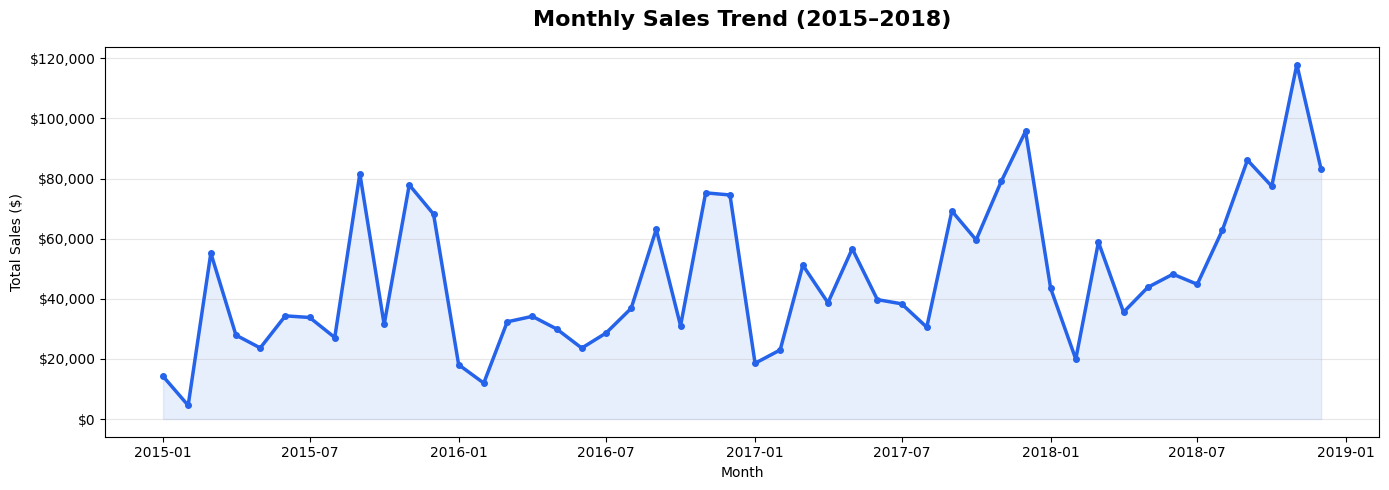

Chart saved as monthly_sales_trend.png


In [ ]:
# Aggregate to monthly sales
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly['Order Date'] = monthly['Order Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Order Date'], monthly['Sales'], color='#2563EB', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(monthly['Order Date'], monthly['Sales'], alpha=0.1, color='#2563EB')
ax.set_title('Monthly Sales Trend (2015–2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as monthly_sales_trend.png')

## Step 6: Build the ML Model

In [ ]:
# Define features and target
FEATURES = [
    'Year', 'Month', 'Quarter', 'DayOfWeek', 'DayOfYear',
    'Days_to_Ship', 'Segment_enc', 'Region_enc',
    'Category_enc', 'Sub-Category_enc', 'Ship Mode_enc'
]
TARGET = 'Sales'

X = df[FEATURES]
y = df[TARGET]

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')

Training samples : 7,840
Testing  samples : 1,960


In [ ]:
# Train Random Forest model
print('Training Random Forest model...')
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Also train a baseline Linear Regression to compare
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(' Models trained!')

Training Random Forest model...
 Models trained!


## Step 7: Evaluate the Model

In [ ]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)  # no negative sales
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f'--- {name} ---')
    print(f'  MAE  (avg error)      : ${mae:,.2f}')
    print(f'  RMSE (penalises big)  : ${rmse:,.2f}')
    print(f'  R²   (fit quality)    : {r2:.3f}  (1.0 = perfect)')
    print()
    return preds

rf_preds = evaluate('Random Forest', rf_model, X_test, y_test)
lr_preds = evaluate('Linear Regression (baseline)', lr_model, X_test, y_test)

--- Random Forest ---
  MAE  (avg error)      : $250.05
  RMSE (penalises big)  : $658.42
  R²   (fit quality)    : -0.063  (1.0 = perfect)

--- Linear Regression (baseline) ---
  MAE  (avg error)      : $279.79
  RMSE (penalises big)  : $637.14
  R²   (fit quality)    : 0.005  (1.0 = perfect)



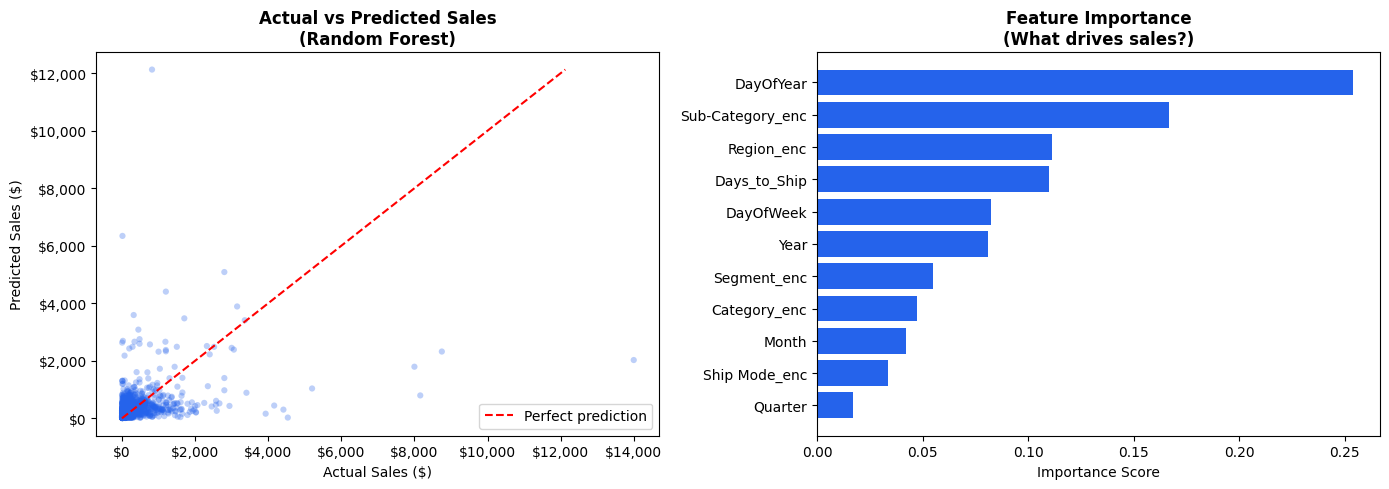

 Saved as model_evaluation.png


In [ ]:
# Plot: Actual vs Predicted (Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(y_test, rf_preds, alpha=0.3, color='#2563EB', edgecolors='none', s=20)
lims = [0, min(y_test.max(), rf_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Sales ($)')
ax.set_ylabel('Predicted Sales ($)')
ax.set_title('Actual vs Predicted Sales\n(Random Forest)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Feature importance
ax = axes[1]
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

ax.barh(importance_df['Feature'], importance_df['Importance'], color='#2563EB')
ax.set_title('Feature Importance\n(What drives sales?)', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved as model_evaluation.png')

## Step 8: Forecast Next 6 Months

In [ ]:
# Build future dates
last_date = df['Order Date'].max()
future_months = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=6, freq='MS')

future_df = pd.DataFrame({
    'Year'            : future_months.year,
    'Month'           : future_months.month,
    'Quarter'         : future_months.quarter,
    'DayOfWeek'       : 0,
    'DayOfYear'       : future_months.day_of_year,
    'Days_to_Ship'    : 4,   # average shipping days
    'Segment_enc'     : 0,
    'Region_enc'      : 2,
    'Category_enc'    : 1,
    'Sub-Category_enc': 5,
    'Ship Mode_enc'   : 1
})

# The model predicts per-order sales. Scale up by avg orders per month.
avg_orders_per_month = len(df) / df['Order Date'].dt.to_period('M').nunique()
forecast_per_order = rf_model.predict(future_df[FEATURES])
forecast_monthly = forecast_per_order * avg_orders_per_month

forecast_df = pd.DataFrame({
    'Month'             : future_months.strftime('%b %Y'),
    'Forecasted Sales'  : forecast_monthly.round(2)
})

print('=== 6-MONTH SALES FORECAST ===')
forecast_df['Forecasted Sales'] = forecast_df['Forecasted Sales'].apply(lambda x: f'${x:,.2f}')
print(forecast_df.to_string(index=False))

=== 6-MONTH SALES FORECAST ===
   Month Forecasted Sales
Jan 2019       $10,683.77
Feb 2019       $19,573.95
Mar 2019       $19,288.34
Apr 2019       $16,217.45
May 2019       $11,901.66
Jun 2019       $14,007.56


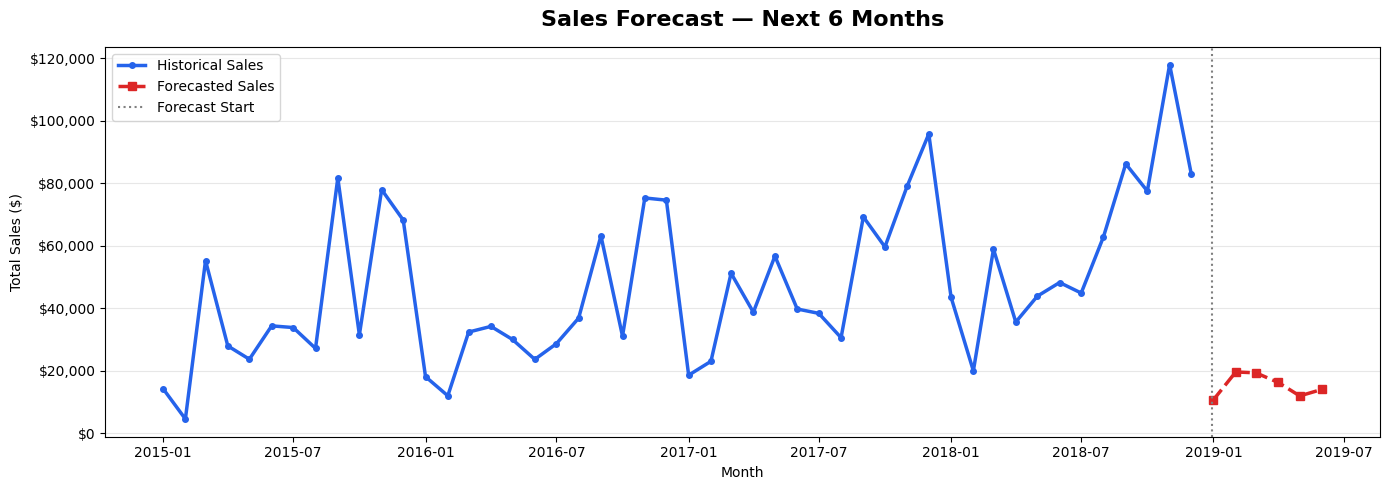

 Saved as sales_forecast.png


In [ ]:
# Plot forecast alongside historical monthly sales
fig, ax = plt.subplots(figsize=(14, 5))

# Historical
ax.plot(monthly['Order Date'], monthly['Sales'],
        color='#2563EB', linewidth=2.5, label='Historical Sales', marker='o', markersize=4)

# Forecast
ax.plot(future_months, forecast_monthly,
        color='#DC2626', linewidth=2.5, linestyle='--', label='Forecasted Sales', marker='s', markersize=6)

ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title('Sales Forecast — Next 6 Months', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved as sales_forecast.png')